# Check RNN constructure Chapter 15 Workshop 1

## Load module

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, SimpleRNN

## Create model

### Simple NN

In [10]:
nn_model = Sequential(name='nn_model')
nn_model.add(Dense(1, input_shape=(1,), name='dense_1'))

In [12]:
nn_model.get_config()

{'name': 'nn_model',
 'layers': [{'class_name': 'InputLayer',
   'config': {'batch_input_shape': (None, 1),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'dense_1_input'}},
  {'class_name': 'Dense',
   'config': {'name': 'dense_1',
    'trainable': True,
    'batch_input_shape': (None, 1),
    'dtype': 'float32',
    'units': 1,
    'activation': 'linear',
    'use_bias': True,
    'kernel_initializer': {'class_name': 'GlorotUniform',
     'config': {'seed': None}},
    'bias_initializer': {'class_name': 'Zeros', 'config': {}},
    'kernel_regularizer': None,
    'bias_regularizer': None,
    'activity_regularizer': None,
    'kernel_constraint': None,
    'bias_constraint': None}}]}

### Simple RNN

In [8]:
rnn_model = Sequential(name='rnn_model')
rnn_model.add(SimpleRNN(units=1, input_shape=(1, 1), activation="relu",name='rnn_1'))

## Model summary

In [11]:
nn_model.summary()
rnn_model.summary()

Model: "nn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
Model: "rnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rnn_1 (SimpleRNN)           (None, 1)                 3         
                                                                 
Total params: 3
Trainable params: 3
Non-trainable params: 0
_________________________________________________________________


## Model weight

In [19]:
for wi in nn_model.layers[0].get_weights():
    print(wi.shape, wi)
print("----------------------------")
for wi in rnn_model.layers[0].get_weights():
    print(wi.shape, wi)

(1, 1) [[1.7162608]]
(1,) [0.]
----------------------------
(1, 1) [[0.57068956]]
(1, 1) [[-1.]]
(1,) [0.]


# Simple RNN Chapter 15 Workshop 2

## Load module

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import  Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

## Set parameter

In [ ]:
pitch = 20  # reset y every 20 steps
step = 1    
N = 100    # number of steps
n_train = int(N*0.7)  # number of training steps

def gen_data(x):            # generate data by mod
    return (x%pitch)/pitch  # normalize to [0,1]

t = np.arange(1,N+1)
# t = np.flip(t)  # reverse time
# y = [gen_data(x) for x in t]  # generate data list
y = gen_data(t)  # generate data numpy array

In [6]:
print(type(y[:10]))

<class 'numpy.ndarray'>


## Visualize data

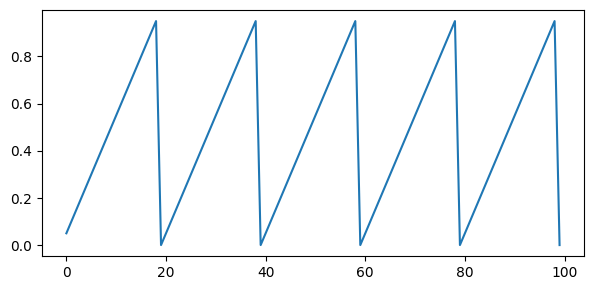

In [7]:
plt.figure(figsize=(7, 3.2))
plt.plot(y)
plt.show()

## Convert to matrix function

In [8]:
def convertToMatrix(data, step=1):
    X, Y = [], []
    for i in range(len(data) - step):
        d = i + step
        X.append(data[i:d,])
        Y.append(data[d,])
    return np.array(X), np.array(Y)

## Create train and test data

In [9]:
train, test = y[:n_train], y[n_train:]
print('train test(before convertToMatrix):', train.shape, test.shape)

train test(before convertToMatrix): (70,) (30,)


In [10]:
X_train, y_train = convertToMatrix(train, step=step)
X_test, y_test = convertToMatrix(test, step=step)
print('train test(after convertToMatrix):', X_train.shape, y_train.shape, X_test.shape, y_test.shape)

train test(after convertToMatrix): (69, 1) (69,) (29, 1) (29,)


## Create model

In [ ]:
model = Sequential(name='rnn_model')
model.add(SimpleRNN(units=3, input_shape=(step, 1), activation="relu", name='rnn_1'))
model.add(Dense(1, name='dense_1'))
model.summary()

Model: "rnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rnn_1 (SimpleRNN)           (None, 3)                 15        
                                                                 
 dense_1 (Dense)             (None, 1)                 4         
                                                                 
Total params: 19
Trainable params: 19
Non-trainable params: 0
_________________________________________________________________
